In [1]:
from util.load import DataLoader
from api.weather import OpenMeteoAPI
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

IndentationError: expected an indented block after 'if' statement on line 188 (load.py, line 190)

In [2]:
loader = DataLoader('../data')
weather = OpenMeteoAPI()
ticker = 'kxhighaus'

results = loader.get_all_market_results(ticker, max_days=275)
weather_forecast = weather.get_daily_weather_forecast(ticker)

In [3]:
daily_data = loader.load_daily_data(ticker, max_days=300)

Loading kxhighaus for 2025-06-07: 100%|██████████| 201/201 [00:00<00:00, 271.77it/s]


In [4]:
kalshi_implied = {}
forecast_rt = {}
for date, df in daily_data.items():
    kalshi_implied[date] = df[df['time_to_strike'] < 60000].iloc[0]['kalshi_fair']
    forecast_rt[date] = df[df['time_to_strike'] < 60000].iloc[0]['forecast']

In [5]:
df = {
    'date': [],
    'kalshi': [],
    'implied': [],
    'forecast_kalshi': []
}
for date, v in results.items():
    forecast = weather_forecast[weather_forecast['time'] == date]
    if forecast.empty or date not in kalshi_implied:
        continue
    for c in forecast.columns:
        if c == 'time' or c not in ['forecast', 'temperature_2m_max_best_match']:
            continue
        if c not in df:
            df[c] = []
        df[c].append(forecast[c].values[0])
    df['date'].append(date)
    df['kalshi'].append(v)
    df['implied'].append(kalshi_implied[date])
    df['forecast_kalshi'].append(forecast_rt[date])
    
df = pd.DataFrame(df)
df.drop(columns=['date'])

,kalshi,implied,forecast_kalshi,temperature_2m_max_best_match,forecast
0,85.5,82.306,67.2,83.4,83.4
1,69.5,70.097,68.5,67.2,67.2
2,73.5,73.630,73.6,72.3,72.3
3,78.5,75.296,77.6,76.3,76.3
4,78.5,78.952,79.3,78.0,78.0
...,...,...,...,...,...
196,92.5,92.598,93.0,91.7,91.7
197,92.5,89.831,91.1,89.8,89.8
198,95.5,94.125,94.0,92.7,92.7
199,96.5,95.887,95.7,94.4,94.4


In [6]:
def remove_outliers(df, features, quantile_range=(0.01, 0.99)):
    mask = np.ones(len(df), dtype=bool)
    for f in features:
        mask = mask & (df[f] >= df[f].quantile(quantile_range[0])) & (df[f] <= df[f].quantile(quantile_range[1]))
    return df[mask]

In [7]:
df['best_forecast_delta'] = df['forecast_kalshi'] - df['kalshi']
df['implied_delta'] = df['implied'] - df['kalshi']

In [8]:
df = remove_outliers(df, ['best_forecast_delta'])

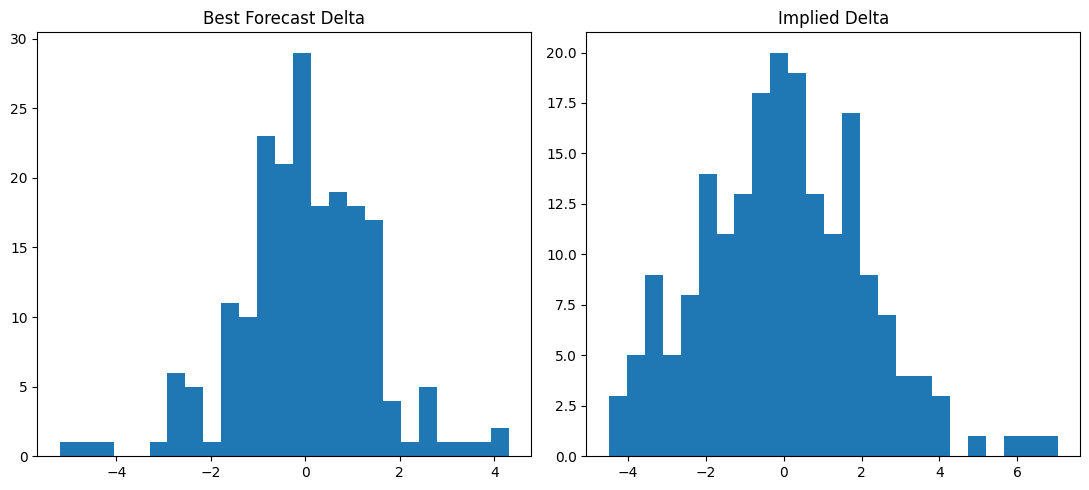

-0.01776649746192879 -0.02516751269035514
1.4210656702193378 2.1076012134314115


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

ax[0].hist(df['best_forecast_delta'], bins=25)
ax[0].set_title('Best Forecast Delta')
ax[1].hist(df['implied_delta'], bins=25)
ax[1].set_title('Implied Delta')

plt.tight_layout()
plt.show()
print(df['best_forecast_delta'].mean(), df['implied_delta'].mean())
print(df['best_forecast_delta'].std(), df['implied_delta'].std())

In [15]:
print(df['best_forecast_delta'].iloc[-20:].mean())

1.3249999999999997


In [14]:
auto_corr = df['best_forecast_delta'].autocorr(lag=1)
print(auto_corr)

0.2379689683012992


In [17]:
dates = sorted(os.listdir('../runtime/execution'))
forecast_trends = {}

forecast_trends = []
for date in dates:
    with open(f'../runtime/execution/{date}', 'r') as f:
        data = f.readlines()
    
    forecasts = []
    for line in data:
        line = json.loads(line)['trade']
        if 'forecast' in line:
            forecast = line['forecast']
        if 'day_forecast_high' in line:
            forecast = line['day_forecast_high']
        if len(forecasts) > 0 and forecasts[-1] == forecast:
            continue
        forecasts.append(forecast)
    forecast_trends.append(forecasts[-1] - forecasts[0])

print(forecast_trends)
print(np.mean(forecast_trends))

[0.7000000000000028, 1.9000000000000057, 0.8000000000000114, 1.5, 2.4000000000000057, 0.09999999999999432, -0.7000000000000028, 0.9500000000000028, 0.0]
0.8500000000000022
